# Electricity Demand Forecasting — v2 (Phase 2)



| Section | What it produces |
|---|---|
| B | Error analysis by peak / off-peak / transition, weekday, month, holiday |
| C | The regime shift: daily error timeline, year-over-year demand drop, degradation quantified |
| D | The fix: retraining cadence experiment (train-once vs retrain-weekly) |
| E | Prediction intervals — quantile models, pinball loss, empirical coverage |
| F | LSTM in **PyTorch**, on the same folds and the same information set (optional) |

Self-contained — rebuilds everything from the CSV. Run top to bottom.

## A. Setup

In [ ]:
from pathlib import Path

# ---- EDIT IF NEEDED ---------------------------------------------------------
DATA_PATH = Path("Electricity Consumption 2015-2020.csv")
# DATA_PATH = Path(r"C:\Users\ahmed\OneDrive\Desktop\Time series forecasting\Electricity Consumption 2015-2020.csv")
# -----------------------------------------------------------------------------

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

COUNTRY      = "TR"
RANDOM_STATE = 42
N_SPLITS     = 4
TEST_HOURS   = 24 * 90
GAP_HOURS    = 24

RUN_LSTM     = True     
LSTM_SEQ_LEN = 72       # hours of history fed to the LSTM (all >= 24h old)

print("Data path:", DATA_PATH.resolve())
print("Exists:   ", DATA_PATH.exists())

Data path: C:\Users\ahmed\OneDrive\Desktop\Time series forecasting\Electricity Consumption 2015-2020.csv
Exists:    True


In [2]:
import warnings, sys, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False

try:
    import holidays as holidays_pkg
    HAS_HOLIDAYS = True
except ImportError:
    HAS_HOLIDAYS = False

try:
    import torch
    import torch.nn as nn
    HAS_TORCH = True
except ImportError:
    HAS_TORCH = False
    print("PyTorch not installed -> Section F will be skipped.")
    print("   To install (CPU):  pip install torch --index-url https://download.pytorch.org/whl/cpu")

np.random.seed(RANDOM_STATE)
plt.rcParams["figure.dpi"] = 110
print(f"lightgbm={HAS_LGB}  holidays={HAS_HOLIDAYS}  torch={HAS_TORCH}")

lightgbm=True  holidays=True  torch=True


In [3]:
# ---- Identical data prep and feature engineering to Phase 1 ------------------

def load_and_clean(path):
    raw = pd.read_csv(path)
    raw["Date"] = pd.to_datetime(raw["Date"], format="%d.%m.%Y")
    col = "Consumption Amount (MWh)"
    if not pd.api.types.is_numeric_dtype(raw[col]):
        raw[col] = (raw[col].astype(str).str.replace(".", "", regex=False)
                    .str.replace(",", ".", regex=False).astype(float))
    raw["DateTime"] = pd.to_datetime(raw["Date"].astype(str) + " " + raw["Time"])
    raw = raw[["DateTime", col]].rename(columns={col: "usage"})
    raw = raw.drop_duplicates(subset="DateTime", keep="first").set_index("DateTime").sort_index()
    raw.loc[raw["usage"] == 0, "usage"] = np.nan
    full = pd.date_range(raw.index.min(), raw.index.max(), freq="h")
    s = raw["usage"].reindex(full).interpolate(method="time", limit_direction="both")
    s.name, s.index.name = "usage", "datetime"
    return s


def get_holiday_dates(idx, country=COUNTRY):
    if not HAS_HOLIDAYS:
        return set()
    try:
        return set(holidays_pkg.country_holidays(
            country, years=range(idx.year.min(), idx.year.max() + 1)).keys())
    except Exception:
        return set()


def make_features(s, min_lag, country=COUNTRY):
    df = pd.DataFrame({"y": s})
    idx = df.index
    seasonal = [24, 25, 48, 72, 168, 169, 336, 720]
    recent = list(range(min_lag, min_lag + 24))
    for L in sorted(set(recent + [L for L in seasonal if L >= min_lag])):
        df[f"lag_{L}"] = s.shift(L)

    base = s.shift(min_lag)
    for w in [24, 168, 720]:
        r = base.rolling(w, min_periods=max(2, w // 4))
        df[f"roll_mean_{w}"], df[f"roll_std_{w}"] = r.mean(), r.std()
        df[f"roll_min_{w}"],  df[f"roll_max_{w}"] = r.min(),  r.max()
    df["diff_24_168"]  = df["roll_mean_24"] - df["roll_mean_168"]
    df["diff_lag_roll"] = df[f"lag_{min_lag}"] - df["roll_mean_168"]

    df["hour"], df["dow"], df["month"] = idx.hour, idx.dayofweek, idx.month
    df["doy"], df["year"] = idx.dayofyear, idx.year
    df["is_weekend"] = (idx.dayofweek >= 5).astype(int)
    for col, period in [("hour", 24), ("dow", 7), ("month", 12), ("doy", 365.25)]:
        df[f"{col}_sin"] = np.sin(2 * np.pi * df[col] / period)
        df[f"{col}_cos"] = np.cos(2 * np.pi * df[col] / period)

    hol = get_holiday_dates(idx, country)
    d = pd.Series(idx.date, index=idx)
    nxt = pd.Series(pd.to_datetime(idx.date) + pd.Timedelta(days=1), index=idx).dt.date
    df["is_holiday"] = d.isin(hol).astype(int).values
    df["is_holiday_eve"] = nxt.isin(hol).astype(int).values
    df["t_index"] = np.arange(len(df))
    return df.dropna()


def metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return {"MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
            "MAPE_%": float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)}


series = load_and_clean(DATA_PATH)
da = make_features(series, min_lag=24)
splitter = TimeSeriesSplit(n_splits=N_SPLITS, test_size=TEST_HOURS, gap=GAP_HOURS)
HOLIDAYS = get_holiday_dates(da.index)

print(f"series {len(series):,} hours | day-ahead frame {da.shape[0]:,} x {da.shape[1]-1} features")

series 39,456 hours | day-ahead frame 38,736 x 61 features


In [4]:
def make_gbm(**kw):
    if HAS_LGB:
        params = dict(n_estimators=1200, learning_rate=0.05, num_leaves=63,
                      min_child_samples=20, subsample=0.8, subsample_freq=1,
                      colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
        params.update(kw)
        return lgb.LGBMRegressor(**params)
    return HistGradientBoostingRegressor(max_iter=1200, learning_rate=0.05, max_leaf_nodes=63,
                                         min_samples_leaf=20, random_state=RANDOM_STATE)

def make_rf():
    return RandomForestRegressor(n_estimators=300, min_samples_leaf=5, max_features=0.5,
                                 random_state=RANDOM_STATE, n_jobs=-1)

# Regenerate backtest predictions for the best model (fast with LightGBM)
X, y = da.drop(columns="y"), da["y"]
rows = []
for i, (tr, te) in enumerate(splitter.split(da), 1):
    m = make_gbm().fit(X.iloc[tr], y.iloc[tr])
    rows.append(pd.DataFrame({"datetime": da.index[te], "y_true": y.iloc[te].values,
                              "y_pred": m.predict(X.iloc[te]), "fold": i}))
preds = pd.concat(rows, ignore_index=True)
preds["error"] = preds.y_pred - preds.y_true
preds["abs_error"] = preds.error.abs()
preds["ape_%"] = (preds.abs_error / preds.y_true) * 100

print("Overall backtest:", {k: round(v, 2) for k, v in metrics(preds.y_true, preds.y_pred).items()})
preds.head()

Overall backtest: {'MAE': np.float64(841.79), 'RMSE': 1285.97, 'MAPE_%': 2.79}


,datetime,y_true,y_pred,fold,error,abs_error,ape_%
0,2019-07-07 00:00:00,35380.45,35382.058369,1,1.608369,1.608369,0.004546
1,2019-07-07 01:00:00,33566.78,33641.974303,1,75.194303,75.194303,0.224014
2,2019-07-07 02:00:00,31823.71,32631.200995,1,807.490995,807.490995,2.537388
3,2019-07-07 03:00:00,30875.39,31479.291277,1,603.901277,603.901277,1.955931
4,2019-07-07 04:00:00,30222.61,30644.160983,1,421.550983,421.550983,1.394820


## B. Error analysis


**Defining the periods from the data, not by guess.** Rank the 24 hours by mean load and cut into
terciles: the top eight are peak, the bottom eight off-peak, the middle eight are the ramp hours
between them — the transition periods.

In [5]:
hourly_mean = series.groupby(series.index.hour).mean()
lo, hi = hourly_mean.quantile([1/3, 2/3])

def label_hour(h):
    if hourly_mean[h] >= hi:  return "Peak"
    if hourly_mean[h] <= lo:  return "Off-peak"
    return "Transition"

hour_label = {h: label_hour(h) for h in range(24)}
preds["hour"] = preds.datetime.dt.hour
preds["period"] = preds.hour.map(hour_label)

print("Hour-of-day classification")
for lab in ["Off-peak", "Transition", "Peak"]:
    hrs = sorted(h for h, l in hour_label.items() if l == lab)
    print(f"  {lab:11s}: {hrs}")

period_tbl = (preds.groupby("period")
              .apply(lambda g: pd.Series({**metrics(g.y_true, g.y_pred),
                                          "mean_load": g.y_true.mean(),
                                          "bias": g.error.mean(),
                                          "n_hours": len(g)}))
              .reindex(["Off-peak", "Transition", "Peak"]).round(2))
print("\nError by demand period")
period_tbl

Hour-of-day classification
  Off-peak   : [0, 1, 2, 3, 4, 5, 6, 7]
  Transition : [8, 9, 10, 12, 13, 21, 22, 23]
  Peak       : [11, 14, 15, 16, 17, 18, 19, 20]

Error by demand period


,MAE,RMSE,MAPE_%,mean_load,bias,n_hours
period,,,,,,
Off-peak,553.31,818.88,2.07,28368.12,-71.88,2880.0
Transition,966.38,1460.54,3.22,33429.93,76.85,2880.0
Peak,1005.69,1468.80,3.09,35247.09,52.90,2880.0


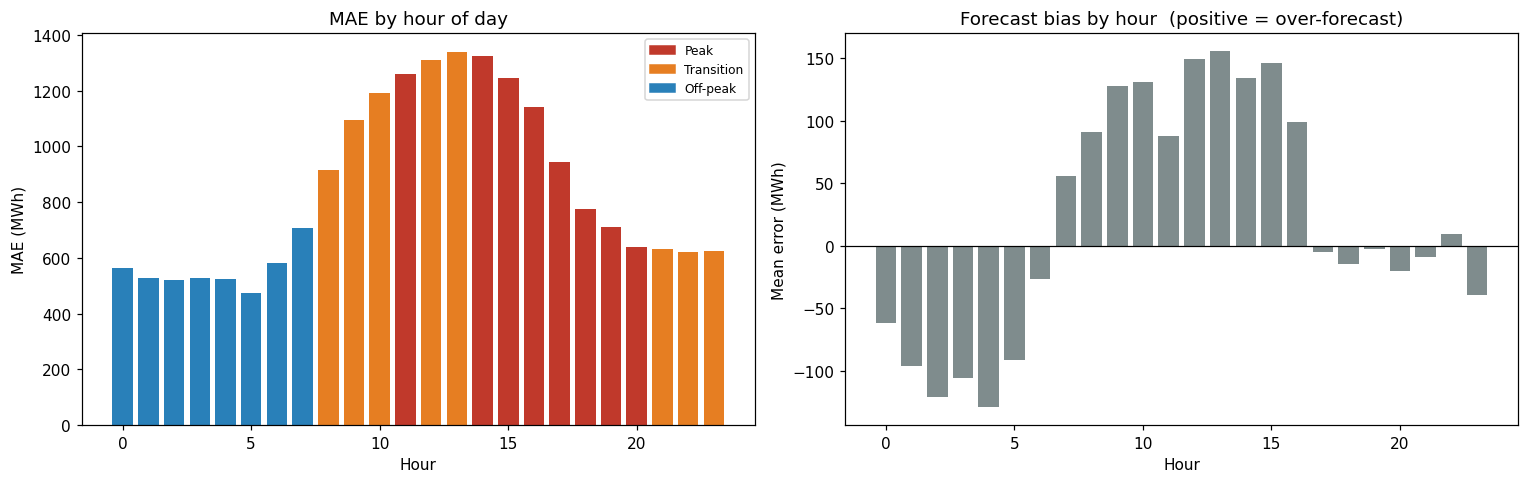

         MAE   bias
hour               
0      563.9  -61.8
1      528.5  -95.8
2      522.3 -120.5
3      528.2 -105.6
4      523.5 -129.1
5      473.1  -91.6
6      580.6  -26.4
7      706.3   55.9
8      915.7   91.0
9     1095.6  127.5
10    1191.7  130.5
11    1260.9   87.5
12    1309.7  148.8
13    1339.3  155.6
14    1325.9  133.9
15    1245.8  145.8
16    1140.9   98.5
17     942.9   -5.3
18     777.0  -14.9
19     712.2   -2.2
20     640.0  -19.9
21     633.0   -8.8
22     622.2    9.5
23     623.8  -39.2


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

by_hour = preds.groupby("hour").agg(MAE=("abs_error", "mean"), bias=("error", "mean"))
colors = {"Peak": "#c0392b", "Transition": "#e67e22", "Off-peak": "#2980b9"}
axes[0].bar(by_hour.index, by_hour.MAE, color=[colors[hour_label[h]] for h in by_hour.index])
axes[0].set_title("MAE by hour of day"); axes[0].set_xlabel("Hour"); axes[0].set_ylabel("MAE (MWh)")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors.values()]
axes[0].legend(handles, colors.keys(), fontsize=8)

axes[1].bar(by_hour.index, by_hour.bias, color="#7f8c8d")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_title("Forecast bias by hour  (positive = over-forecast)")
axes[1].set_xlabel("Hour"); axes[1].set_ylabel("Mean error (MWh)")
plt.tight_layout(); plt.show()

print(by_hour.round(1).to_string())

In [7]:
# Weekday / weekend / holiday breakdown
preds["dow"] = preds.datetime.dt.day_name()
preds["is_holiday"] = preds.datetime.dt.date.isin(HOLIDAYS)
preds["month"] = preds.datetime.dt.to_period("M").astype(str)

dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_tbl = (preds.groupby("dow").apply(lambda g: pd.Series(metrics(g.y_true, g.y_pred)))
           .reindex(dow_order).round(2))

hol_tbl = (preds.groupby("is_holiday")
           .apply(lambda g: pd.Series({**metrics(g.y_true, g.y_pred), "n_hours": len(g)}))
           .rename(index={False: "Normal day", True: "Public holiday"}).round(2))

print("Error by weekday\n", dow_tbl.to_string())
print("\nError on holidays vs normal days\n", hol_tbl.to_string())
if len(hol_tbl) == 2:
    ratio = hol_tbl.loc["Public holiday", "MAE"] / hol_tbl.loc["Normal day", "MAE"]
    print(f"\n-> Holiday MAE is {ratio:.2f}x the normal-day MAE")

Error by weekday
                MAE     RMSE  MAPE_%
dow                                
Monday     1165.43  1688.67    3.67
Tuesday     851.39  1154.45    2.74
Wednesday   722.16  1040.66    2.26
Thursday    661.87  1001.86    2.00
Friday      682.74  1046.82    2.17
Saturday   1004.14  1682.81    3.61
Sunday      799.12  1168.62    3.09

Error on holidays vs normal days
                     MAE     RMSE  MAPE_%  n_hours
is_holiday                                       
Normal day       794.30  1209.80    2.57   8304.0
Public holiday  2015.42  2520.26    8.33    336.0

-> Holiday MAE is 2.54x the normal-day MAE


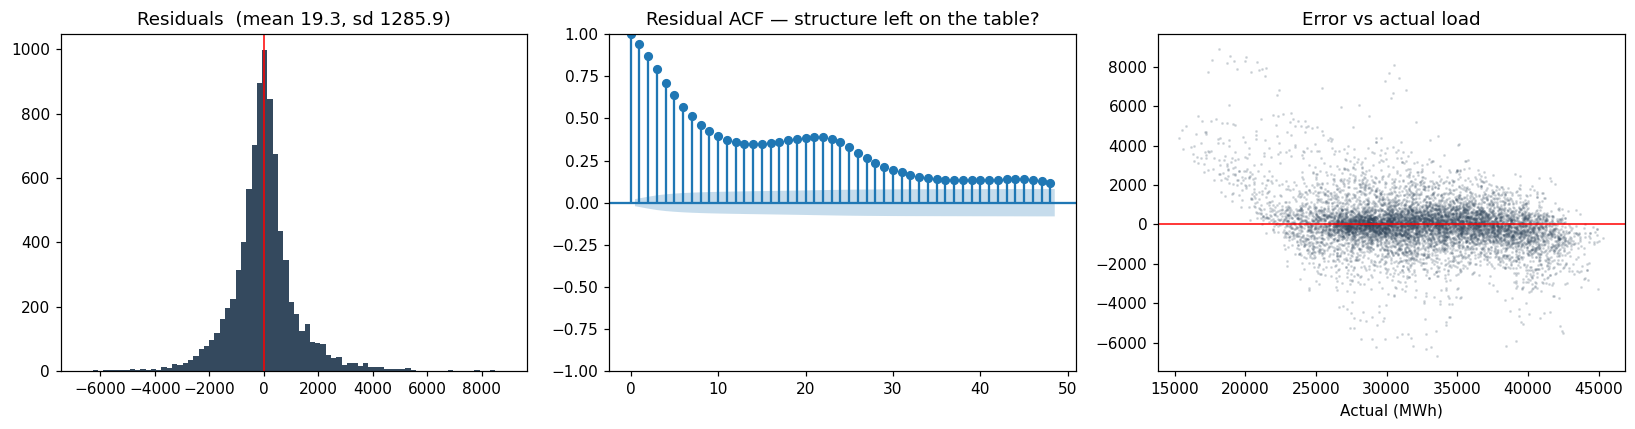

Mean bias: 19.3 MWh  (0.06% of mean load)
A near-zero mean means the model is unbiased. Large ACF spikes mean predictable
structure remains in the residuals and more feature work would pay off.


In [8]:
# Residual diagnostics: is the error white noise, or is there structure left?
from statsmodels.graphics.tsaplots import plot_acf

resid = preds.sort_values("datetime").set_index("datetime")["error"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(resid, bins=80, color="#34495e")
axes[0].axvline(0, color="r", lw=1)
axes[0].set_title(f"Residuals  (mean {resid.mean():.1f}, sd {resid.std():.1f})")

plot_acf(resid.dropna(), lags=48, ax=axes[1])
axes[1].set_title("Residual ACF — structure left on the table?")

axes[2].scatter(preds.y_true, preds.error, s=1, alpha=0.15, color="#34495e")
axes[2].axhline(0, color="r", lw=1)
axes[2].set_title("Error vs actual load"); axes[2].set_xlabel("Actual (MWh)")
plt.tight_layout(); plt.show()

print(f"Mean bias: {resid.mean():,.1f} MWh  ({resid.mean()/preds.y_true.mean()*100:.2f}% of mean load)")
print("A near-zero mean means the model is unbiased. Large ACF spikes mean predictable")
print("structure remains in the residuals and more feature work would pay off.")

## C. The regime shift

Phase 1's fold 4 (Apr–Jun 2020) degraded 2.6x while the naive baselines held steady. That pattern —
learned models collapsing while trivial ones survive — is the signature of **distribution shift**:
the relationship the model learned stopped describing the world.

Below: when it started, how large it was, and the demand drop that caused it.

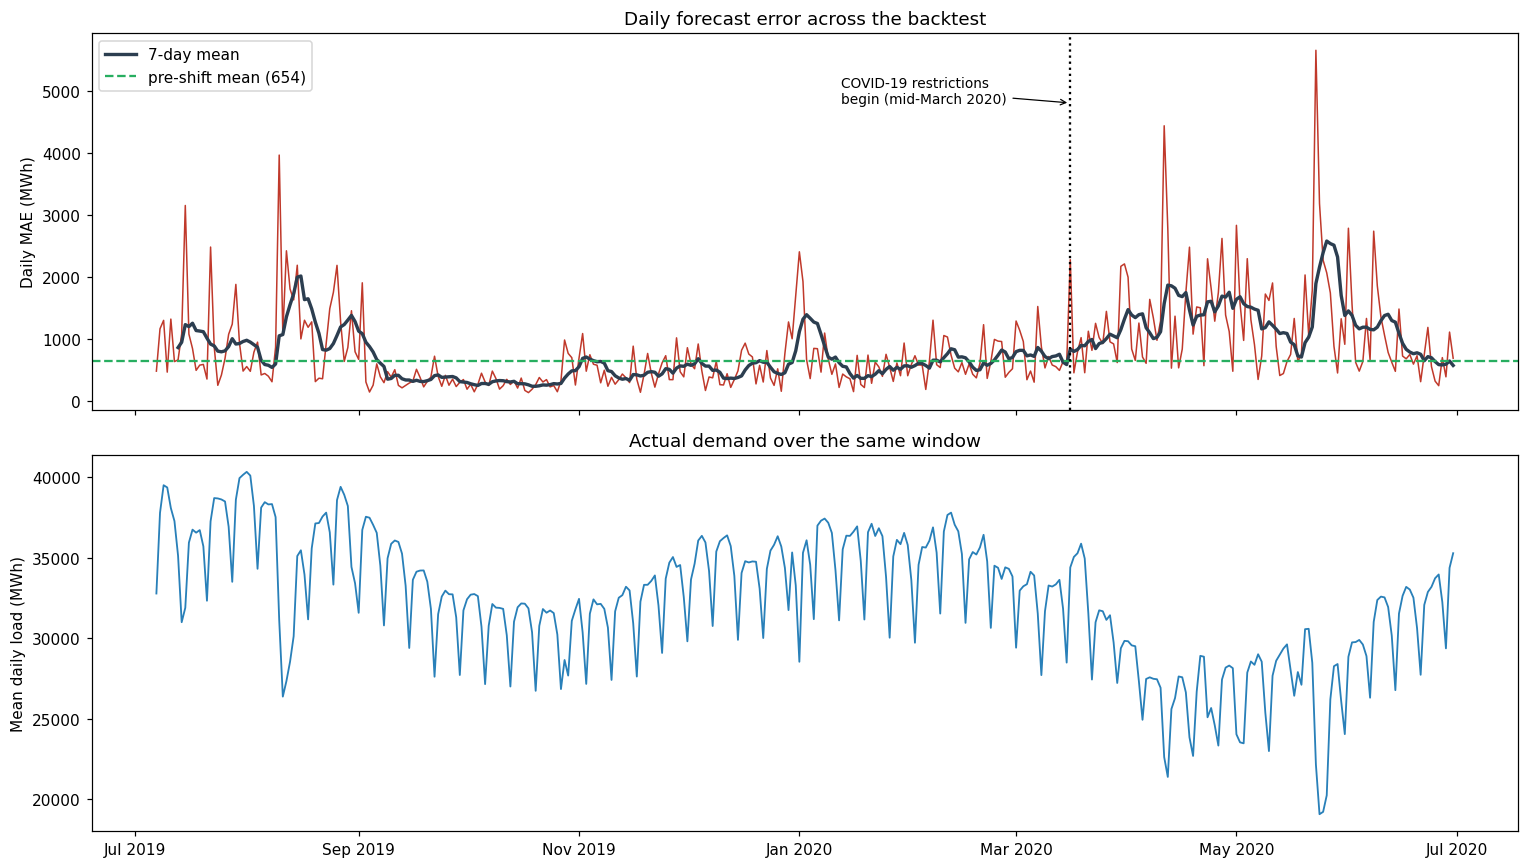

In [9]:
daily = (preds.set_index("datetime")
         .resample("D").agg(MAE=("abs_error", "mean"), load=("y_true", "mean")).dropna())

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(daily.index, daily.MAE, lw=1, color="#c0392b")
axes[0].plot(daily.index, daily.MAE.rolling(7).mean(), lw=2.2, color="#2c3e50", label="7-day mean")
baseline_mae = daily.loc[:"2020-02-29", "MAE"].mean()
axes[0].axhline(baseline_mae, ls="--", color="#27ae60", label=f"pre-shift mean ({baseline_mae:,.0f})")
axes[0].axvline(pd.Timestamp("2020-03-16"), ls=":", color="k")
axes[0].annotate("COVID-19 restrictions\nbegin (mid-March 2020)", xy=(pd.Timestamp("2020-03-16"), daily.MAE.max()*0.85),
                 xytext=(-150, 0), textcoords="offset points", fontsize=9,
                 arrowprops=dict(arrowstyle="->", lw=0.8))
axes[0].set_ylabel("Daily MAE (MWh)"); axes[0].legend(); axes[0].set_title("Daily forecast error across the backtest")

axes[1].plot(daily.index, daily.load, lw=1.2, color="#2980b9")
axes[1].set_ylabel("Mean daily load (MWh)"); axes[1].set_title("Actual demand over the same window")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.tight_layout(); plt.show()

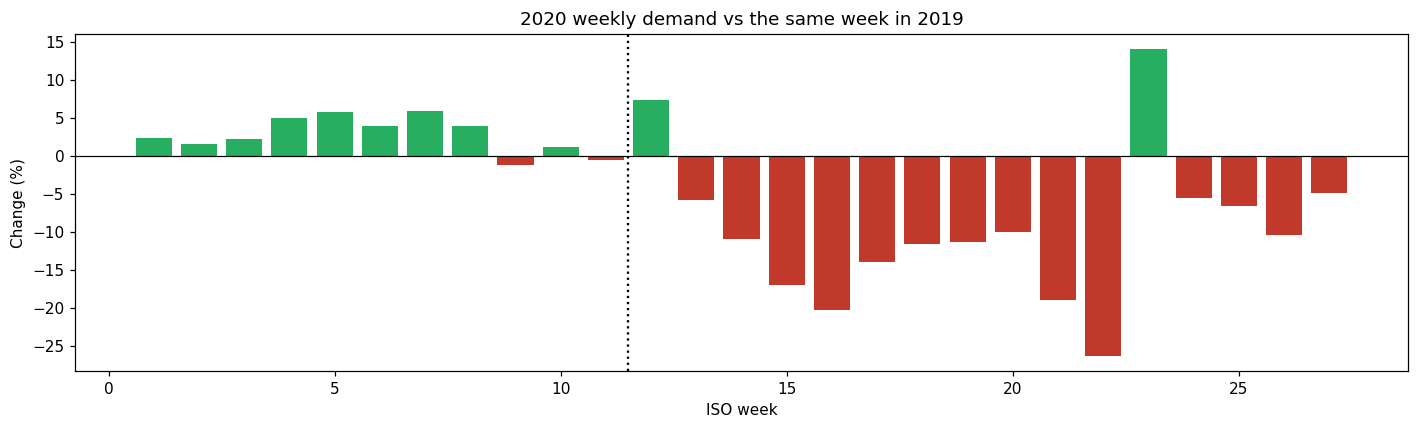

Largest year-over-year drop: week 22, -26.3% below 2019
Mean change, weeks 1-11  (pre-restriction) : +2.8%
Mean change, weeks 12-26 (restrictions)    : -9.5%


In [10]:
# How big was the demand shock? Compare 2020 against the same calendar weeks in 2019.
s = series.to_frame("load")
s["year"], s["week"] = s.index.isocalendar().year, s.index.isocalendar().week
wk = s.groupby(["year", "week"]).load.mean().unstack(0)

common = [c for c in [2019, 2020] if c in wk.columns]
if len(common) == 2:
    cmp = wk[common].dropna()
    cmp["change_%"] = (cmp[2020] / cmp[2019] - 1) * 100

    fig, ax = plt.subplots(figsize=(13, 4))
    ax.bar(cmp.index, cmp["change_%"], color=np.where(cmp["change_%"] < 0, "#c0392b", "#27ae60"))
    ax.axhline(0, color="k", lw=0.8)
    ax.axvline(11.5, ls=":", color="k")
    ax.set_title("2020 weekly demand vs the same week in 2019")
    ax.set_xlabel("ISO week"); ax.set_ylabel("Change (%)")
    plt.tight_layout(); plt.show()

    trough = cmp["change_%"].idxmin()
    print(f"Largest year-over-year drop: week {trough}, {cmp['change_%'].min():.1f}% below 2019")
    print(f"Mean change, weeks 1-11  (pre-restriction) : {cmp.loc[:11,  'change_%'].mean():+.1f}%")
    print(f"Mean change, weeks 12-26 (restrictions)    : {cmp.loc[12:, 'change_%'].mean():+.1f}%")

In [11]:
# Quantify the degradation on a fixed before/after cut
CUT = pd.Timestamp("2020-03-16")
before = preds[preds.datetime < CUT]
after  = preds[preds.datetime >= CUT]

shift_tbl = pd.DataFrame({
    "Before shift": {**metrics(before.y_true, before.y_pred), "days": before.datetime.dt.date.nunique()},
    "After shift":  {**metrics(after.y_true,  after.y_pred),  "days": after.datetime.dt.date.nunique()},
}).T.round(2)
shift_tbl.loc["Degradation", :] = [
    shift_tbl.loc["After shift", c] / shift_tbl.loc["Before shift", c] for c in shift_tbl.columns]
print(shift_tbl.round(2).to_string())
print(f"\n-> MAE rose {shift_tbl.loc['Degradation','MAE']:.2f}x after restrictions began.")

                  MAE     RMSE  MAPE_%    days
Before shift   659.57   996.30    1.93  253.00
After shift   1272.66  1793.56    4.83  107.00
Degradation      1.93     1.80    2.50    0.42

-> MAE rose 1.93x after restrictions began.


## D. The fix: retraining cadence

The diagnosis says the model relied on week-old and two-week-old demand (`lag_168` and `lag_336`
were 52% of its importance in Phase 1), so a level shift within days makes it stale.

The cheapest fix is not a new model — it is **retraining more often**. Below, two deployments over
the shock window:

- **Train once** — fit at the start, never update. What most portfolio projects implicitly assume.
- **Retrain weekly** — refit every 7 days on everything available up to 24h before. What a real
  pipeline would do.

Identical features, identical model. Only the cadence changes.

In [12]:
tr_idx, te_idx = list(splitter.split(da))[-1]
fold_start, fold_end = da.index[te_idx[0]], da.index[te_idx[-1]]
print(f"Evaluation window: {fold_start.date()} -> {fold_end.date()}")

# --- Strategy 1: train once ---------------------------------------------------
static = make_gbm().fit(X.iloc[tr_idx], y.iloc[tr_idx])
static_pred = pd.Series(static.predict(X.iloc[te_idx]), index=da.index[te_idx])

# --- Strategy 2: retrain weekly ----------------------------------------------
weekly_pred, n_fits = [], 0
cursor = fold_start
while cursor <= fold_end:
    chunk_end = min(cursor + pd.Timedelta(days=7) - pd.Timedelta(hours=1), fold_end)
    train_mask = da.index <= (cursor - pd.Timedelta(hours=GAP_HOURS))
    test_mask  = (da.index >= cursor) & (da.index <= chunk_end)
    if test_mask.sum():
        m = make_gbm().fit(X[train_mask], y[train_mask])
        weekly_pred.append(pd.Series(m.predict(X[test_mask]), index=da.index[test_mask]))
        n_fits += 1
    cursor = chunk_end + pd.Timedelta(hours=1)
weekly_pred = pd.concat(weekly_pred)
print(f"Weekly strategy refit {n_fits} times")

truth = y.loc[static_pred.index]
cadence = pd.DataFrame({
    "Train once":     metrics(truth, static_pred),
    "Retrain weekly": metrics(truth, weekly_pred.loc[truth.index]),
}).T.round(2)
cadence["MAE_reduction_%"] = ((cadence.loc["Train once", "MAE"] - cadence.MAE)
                              / cadence.loc["Train once", "MAE"] * 100).round(1)
cadence

Evaluation window: 2020-04-02 -> 2020-06-30
Weekly strategy refit 13 times


,MAE,RMSE,MAPE_%,MAE_reduction_%
Train once,1284.63,1830.65,5.02,0.0
Retrain weekly,1132.22,1658.95,4.40,11.9


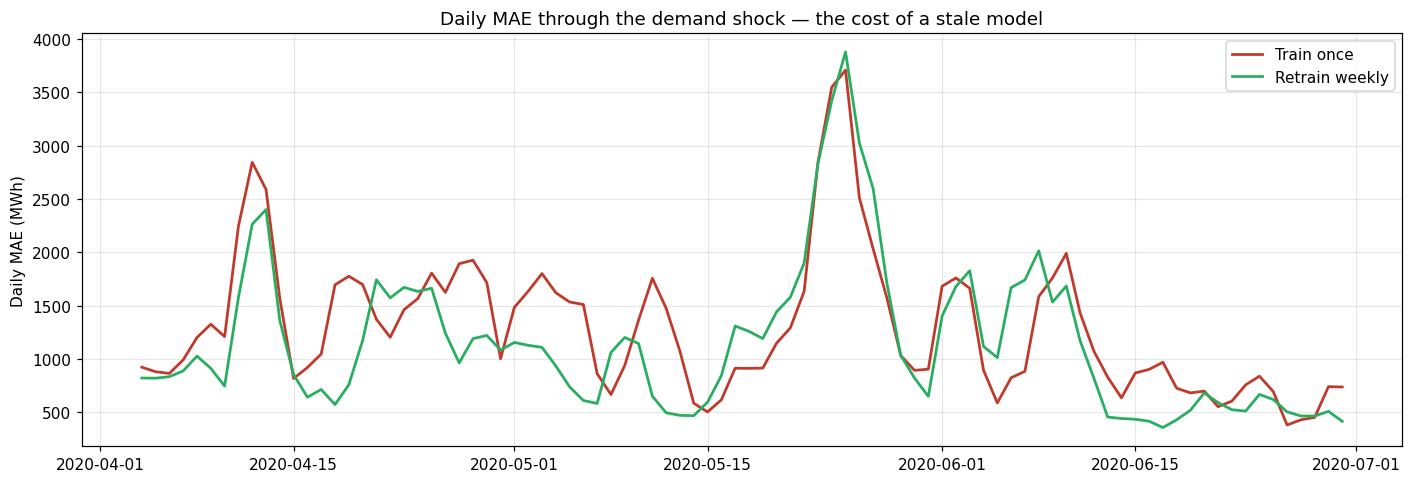

In [13]:
comp = pd.DataFrame({"truth": truth, "once": static_pred,
                     "weekly": weekly_pred.loc[truth.index]})
d = pd.DataFrame({
    "Train once":     (comp.once - comp.truth).abs(),
    "Retrain weekly": (comp.weekly - comp.truth).abs(),
}).resample("D").mean()

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(d.index, d["Train once"].rolling(3).mean(), lw=1.8, color="#c0392b", label="Train once")
ax.plot(d.index, d["Retrain weekly"].rolling(3).mean(), lw=1.8, color="#27ae60", label="Retrain weekly")
ax.set_title("Daily MAE through the demand shock — the cost of a stale model")
ax.set_ylabel("Daily MAE (MWh)"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## E. Prediction intervals

A grid operator does not schedule generation on a point forecast. They need a range and a stated
confidence — reserve capacity is priced off the upper bound.

Quantile regression at the 5th, 50th and 95th percentiles, scored two ways:

- **Pinball loss** — the proper scoring rule for quantile forecasts
- **Empirical coverage** — how often the true value actually landed inside the 90% band.
  A well-calibrated band covers ~90%. Much less and it is overconfident; much more and it is so wide
  it is useless.

In [14]:
def pinball_loss(y_true, y_pred, q):
    d = np.asarray(y_true, float) - np.asarray(y_pred, float)
    return float(np.mean(np.maximum(q * d, (q - 1) * d)))

QUANTILES = [0.05, 0.50, 0.95]
q_rows = []

for i, (tr, te) in enumerate(splitter.split(da), 1):
    out = {"fold": i, "datetime": da.index[te], "y_true": y.iloc[te].values}
    for q in QUANTILES:
        if HAS_LGB:
            mq = lgb.LGBMRegressor(objective="quantile", alpha=q, n_estimators=800,
                                   learning_rate=0.05, num_leaves=63, min_child_samples=20,
                                   random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
        else:
            mq = HistGradientBoostingRegressor(loss="quantile", quantile=q, max_iter=800,
                                               learning_rate=0.05, max_leaf_nodes=63,
                                               random_state=RANDOM_STATE)
        mq.fit(X.iloc[tr], y.iloc[tr])
        out[f"q{int(q*100):02d}"] = mq.predict(X.iloc[te])
    q_rows.append(pd.DataFrame(out))
    print(f"fold {i} done")

qp = pd.concat(q_rows, ignore_index=True)
qp["covered"] = (qp.y_true >= qp.q05) & (qp.y_true <= qp.q95)
qp["width"] = qp.q95 - qp.q05

fold 1 done
fold 2 done
fold 3 done
fold 4 done


In [15]:
cal = pd.DataFrame({
    "Coverage_% (target 90)": [qp.covered.mean() * 100],
    "Mean interval width":    [qp.width.mean()],
    "Width as % of load":     [qp.width.mean() / qp.y_true.mean() * 100],
    "Pinball q05":            [pinball_loss(qp.y_true, qp.q05, 0.05)],
    "Pinball q50":            [pinball_loss(qp.y_true, qp.q50, 0.50)],
    "Pinball q95":            [pinball_loss(qp.y_true, qp.q95, 0.95)],
}).T.round(2)
cal.columns = ["value"]
print(cal.to_string())

print("\nCoverage by fold (watch fold 4 — the shock window):")
print((qp.groupby("fold").agg(coverage_pct=("covered", lambda c: c.mean()*100),
                              mean_width=("width", "mean"))).round(1).to_string())

                          value
Coverage_% (target 90)    65.72
Mean interval width     2058.15
Width as % of load         6.36
Pinball q05              205.34
Pinball q50              427.21
Pinball q95              138.74

Coverage by fold (watch fold 4 — the shock window):
      coverage_pct  mean_width
fold                          
1             67.6      2159.4
2             67.5      1413.4
3             72.1      2153.8
4             55.7      2506.1


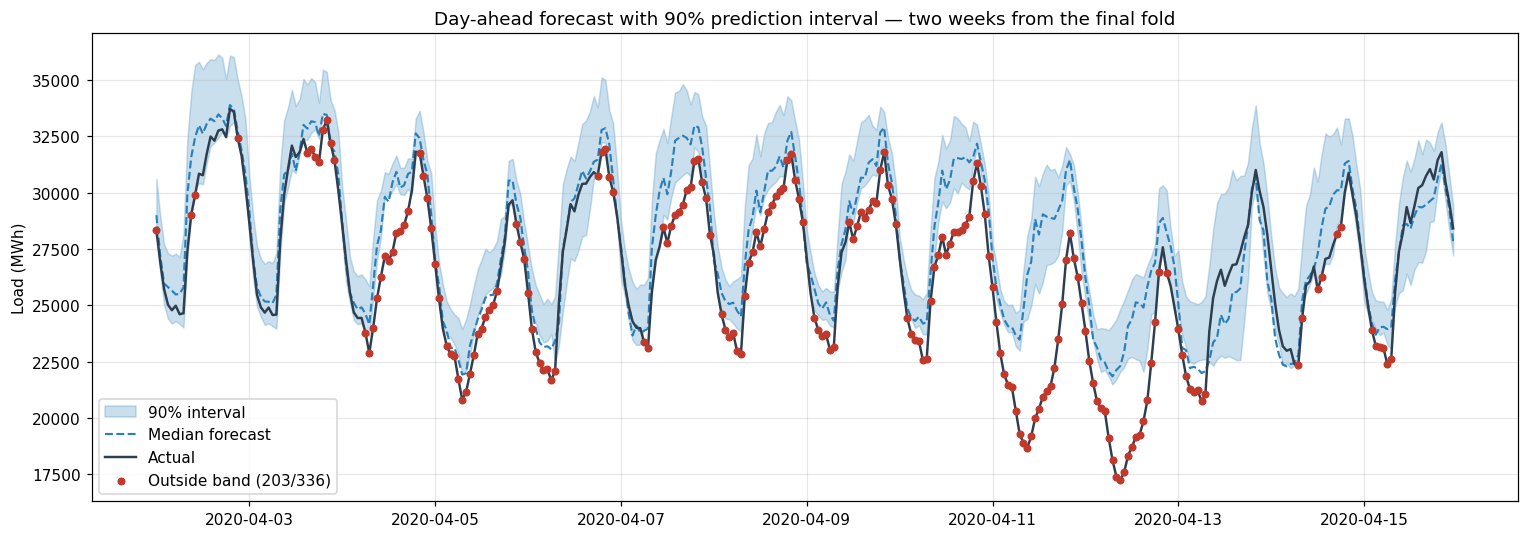

In [16]:
# Two weeks from the shock window, with the uncertainty band
w = qp[qp.fold == qp.fold.max()].set_index("datetime").iloc[:24*14]

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(w.index, w.q05, w.q95, alpha=0.25, color="#2980b9", label="90% interval")
ax.plot(w.index, w.q50, lw=1.4, ls="--", color="#2980b9", label="Median forecast")
ax.plot(w.index, w.y_true, lw=1.6, color="#2c3e50", label="Actual")
miss = w[~((w.y_true >= w.q05) & (w.y_true <= w.q95))]
ax.scatter(miss.index, miss.y_true, s=18, color="#c0392b", zorder=5,
           label=f"Outside band ({len(miss)}/{len(w)})")
ax.set_title("Day-ahead forecast with 90% prediction interval — two weeks from the final fold")
ax.set_ylabel("Load (MWh)"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## F. LSTM in PyTorch


In [17]:
STATIC_COLS = ["hour_sin","hour_cos","dow_sin","dow_cos","doy_sin","doy_cos",
               "is_holiday","is_holiday_eve","is_weekend","lag_168","lag_336","roll_mean_168"]

def build_sequences(s, index, seq_len, min_lag):
    """(n, seq_len) array of past load, oldest first, newest value min_lag hours before target."""
    cols = [s.shift(min_lag + k).reindex(index).values for k in range(seq_len - 1, -1, -1)]
    return np.stack(cols, axis=1)

if RUN_LSTM and HAS_TORCH:
    seq_all = build_sequences(series, da.index, LSTM_SEQ_LEN, 24)
    stat_all = da[STATIC_COLS].values
    valid = ~np.isnan(seq_all).any(axis=1)
    print(f"sequences {seq_all.shape} | static {stat_all.shape} | usable rows {valid.sum():,}")

sequences (38736, 72) | static (38736, 12) | usable rows 38,736


In [18]:
if RUN_LSTM and HAS_TORCH:
    class LSTMForecaster(nn.Module):
        def __init__(self, n_static, hidden=64):
            super().__init__()
            self.lstm = nn.LSTM(1, hidden, num_layers=1, batch_first=True)
            self.head = nn.Sequential(
                nn.Linear(hidden + n_static, 64), nn.ReLU(), nn.Dropout(0.1), nn.Linear(64, 1))

        def forward(self, seq, stat):
            _, (h, _) = self.lstm(seq)
            return self.head(torch.cat([h[-1], stat], dim=1)).squeeze(-1)

    def train_lstm(seq_tr, stat_tr, y_tr, seq_va, stat_va, y_va,
                   max_epochs=25, patience=3, batch=512, lr=1e-3):
        torch.manual_seed(RANDOM_STATE)
        model = LSTMForecaster(stat_tr.shape[1])
        opt = torch.optim.Adam(model.parameters(), lr=lr)
        lossf = nn.MSELoss()
        ds = torch.utils.data.TensorDataset(*[torch.tensor(a, dtype=torch.float32)
                                              for a in (seq_tr, stat_tr, y_tr)])
        dl = torch.utils.data.DataLoader(ds, batch_size=batch, shuffle=True)
        vs, vt, vy = [torch.tensor(a, dtype=torch.float32) for a in (seq_va, stat_va, y_va)]

        best, best_state, bad = np.inf, None, 0
        for ep in range(max_epochs):
            model.train()
            for sb, tb, yb in dl:
                opt.zero_grad()
                lossf(model(sb.unsqueeze(-1), tb), yb).backward()
                opt.step()
            model.eval()
            with torch.no_grad():
                vl = lossf(model(vs.unsqueeze(-1), vt), vy).item()
            if vl < best - 1e-6:
                best, best_state, bad = vl, {k: v.clone() for k, v in model.state_dict().items()}, 0
            else:
                bad += 1
                if bad >= patience:
                    break
        model.load_state_dict(best_state)
        return model, ep + 1

    # Fast shape self-test: catches a broken model in 2 seconds instead of 20 minutes
    _m = LSTMForecaster(n_static=len(STATIC_COLS))
    _seq = torch.randn(8, LSTM_SEQ_LEN, 1)
    _stat = torch.randn(8, len(STATIC_COLS))
    with torch.no_grad():
        _out = _m(_seq, _stat)
    assert _out.shape == (8,), f"expected (8,), got {tuple(_out.shape)}"
    print(f"LSTM defined and shape-checked: (8, {LSTM_SEQ_LEN}, 1) + (8, {len(STATIC_COLS)}) -> (8,)")

LSTM defined and shape-checked: (8, 72, 1) + (8, 12) -> (8,)


In [19]:
if RUN_LSTM and HAS_TORCH:
    lstm_rows, lstm_preds = [], []
    for i, (tr, te) in enumerate(splitter.split(da), 1):
        t0 = time.time()
        tr = tr[valid[tr]]
        te_v = te[valid[te]]

        # scalers fit on TRAIN ONLY
        sc_seq, sc_stat, sc_y = StandardScaler(), StandardScaler(), StandardScaler()
        seq_tr = sc_seq.fit_transform(seq_all[tr].reshape(-1, 1)).reshape(len(tr), -1)
        seq_te = sc_seq.transform(seq_all[te_v].reshape(-1, 1)).reshape(len(te_v), -1)
        stat_tr = sc_stat.fit_transform(stat_all[tr])
        stat_te = sc_stat.transform(stat_all[te_v])
        y_tr = sc_y.fit_transform(y.values[tr].reshape(-1, 1)).ravel()

        cut = int(len(tr) * 0.9)          # last 10% of train = validation, chronological
        model, eps = train_lstm(seq_tr[:cut], stat_tr[:cut], y_tr[:cut],
                                seq_tr[cut:], stat_tr[cut:], y_tr[cut:])

        model.eval()
        with torch.no_grad():
            p = model(torch.tensor(seq_te, dtype=torch.float32).unsqueeze(-1),
                      torch.tensor(stat_te, dtype=torch.float32)).numpy()
        p = sc_y.inverse_transform(p.reshape(-1, 1)).ravel()

        m = metrics(y.values[te_v], p)
        m.update({"fold": i, "epochs": eps, "seconds": round(time.time() - t0, 1)})
        lstm_rows.append(m)
        lstm_preds.append(pd.DataFrame({"datetime": da.index[te_v], "y_true": y.values[te_v],
                                        "y_pred": p, "fold": i}))
        print(f"fold {i}: MAE {m['MAE']:,.1f}  ({eps} epochs, {m['seconds']}s)")

    lstm_results = pd.DataFrame(lstm_rows)
    lstm_predictions = pd.concat(lstm_preds, ignore_index=True)
    print("\n", lstm_results.round(2).to_string())

fold 1: MAE 812.0  (17 epochs, 79.1s)
fold 2: MAE 535.3  (22 epochs, 122.0s)
fold 3: MAE 727.5  (17 epochs, 95.9s)
fold 4: MAE 1,230.6  (25 epochs, 153.0s)

        MAE     RMSE  MAPE_%  fold  epochs  seconds
0   811.98  1185.57    2.41     1      17     79.1
1   535.31   864.29    1.64     2      22    122.0
2   727.55  1046.32    2.14     3      17     95.9
3  1230.62  1677.93    4.77     4      25    153.0


In [20]:
# Final head-to-head on identical folds and identical information
gbm_by_fold = preds.groupby("fold").apply(lambda g: pd.Series(metrics(g.y_true, g.y_pred)))
comparison = {"LightGBM" if HAS_LGB else "HistGradientBoosting": gbm_by_fold.mean().to_dict()}

if RUN_LSTM and HAS_TORCH:
    comparison["LSTM (PyTorch)"] = lstm_results[["MAE", "RMSE", "MAPE_%"]].mean().to_dict()

sn = pd.DataFrame({"y_true": da["y"], "y_pred": da["lag_24"]})
sn_scores = []
for i, (tr, te) in enumerate(splitter.split(da), 1):
    sn_scores.append(metrics(sn.y_true.iloc[te], sn.y_pred.iloc[te]))
comparison["Seasonal naive (t-24)"] = pd.DataFrame(sn_scores).mean().to_dict()

final = pd.DataFrame(comparison).T.sort_values("MAE").round(2)
base = final.loc["Seasonal naive (t-24)", "MAE"]
final["vs_naive_%"] = ((base - final.MAE) / base * 100).round(1)
print("Day-ahead forecasting — 4-fold rolling-origin backtest\n")
final

Day-ahead forecasting — 4-fold rolling-origin backtest



,MAE,RMSE,MAPE_%,vs_naive_%
LSTM (PyTorch),826.36,1193.53,2.74,55.9
LightGBM,841.79,1228.97,2.79,55.0
Seasonal naive (t-24),1872.50,2944.25,5.98,0.0


## G. Save and report

In [21]:
preds.to_csv(OUTPUT_DIR / "p2_predictions_gbm.csv", index=False)
period_tbl.to_csv(OUTPUT_DIR / "p2_error_by_period.csv")
qp.to_csv(OUTPUT_DIR / "p2_quantile_predictions.csv", index=False)
cadence.to_csv(OUTPUT_DIR / "p2_retraining_cadence.csv")
final.to_csv(OUTPUT_DIR / "p2_final_comparison.csv")
if RUN_LSTM and HAS_TORCH:
    lstm_results.to_csv(OUTPUT_DIR / "p2_lstm_results.csv", index=False)

print("Saved to", OUTPUT_DIR.resolve())
for f in sorted(OUTPUT_DIR.iterdir()):
    print("  -", f.name)

Saved to C:\Users\ahmed\OneDrive\Desktop\Time series forecasting\outputs
  - backtest_results.csv
  - backtest_summary.csv
  - data_audit.csv
  - feature_importance.csv
  - p2_error_by_period.csv
  - p2_final_comparison.csv
  - p2_lstm_results.csv
  - p2_predictions_gbm.csv
  - p2_quantile_predictions.csv
  - p2_retraining_cadence.csv
  - predictions.csv


In [22]:
# ===== PASTE THIS BLOCK'S OUTPUT BACK INTO THE CHAT ==========================
print("### ERROR BY DEMAND PERIOD")
print(period_tbl.to_string())

print("\n### ERROR BY WEEKDAY")
print(dow_tbl.to_string())

print("\n### HOLIDAY VS NORMAL")
print(hol_tbl.to_string())

print("\n### MAE BY HOUR")
print(by_hour.round(1).to_string())

print("\n### RESIDUALS")
print(f"mean bias: {resid.mean():.1f} MWh | sd: {resid.std():.1f}")

print("\n### REGIME SHIFT (cut 2020-03-16)")
print(shift_tbl.round(2).to_string())

print("\n### RETRAINING CADENCE")
print(cadence.to_string())

print("\n### PREDICTION INTERVALS")
print(cal.to_string())
print(qp.groupby("fold").agg(coverage_pct=("covered", lambda c: c.mean()*100),
                             mean_width=("width","mean")).round(1).to_string())

print("\n### FINAL MODEL COMPARISON")
print(final.to_string())

if RUN_LSTM and HAS_TORCH:
    print("\n### LSTM PER FOLD")
    print(lstm_results.round(2).to_string())

print(f"\n### ENV  lightgbm={HAS_LGB} holidays={HAS_HOLIDAYS} torch={HAS_TORCH} lstm_run={RUN_LSTM}")
# =============================================================================

### ERROR BY DEMAND PERIOD
                MAE     RMSE  MAPE_%  mean_load   bias  n_hours
period                                                         
Off-peak     553.31   818.88    2.07   28368.12 -71.88   2880.0
Transition   966.38  1460.54    3.22   33429.93  76.85   2880.0
Peak        1005.69  1468.80    3.09   35247.09  52.90   2880.0

### ERROR BY WEEKDAY
               MAE     RMSE  MAPE_%
dow                                
Monday     1165.43  1688.67    3.67
Tuesday     851.39  1154.45    2.74
Wednesday   722.16  1040.66    2.26
Thursday    661.87  1001.86    2.00
Friday      682.74  1046.82    2.17
Saturday   1004.14  1682.81    3.61
Sunday      799.12  1168.62    3.09

### HOLIDAY VS NORMAL
                    MAE     RMSE  MAPE_%  n_hours
is_holiday                                       
Normal day       794.30  1209.80    2.57   8304.0
Public holiday  2015.42  2520.26    8.33    336.0

### MAE BY HOUR
         MAE   bias
hour               
0      563.9  -61.8
1      